   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

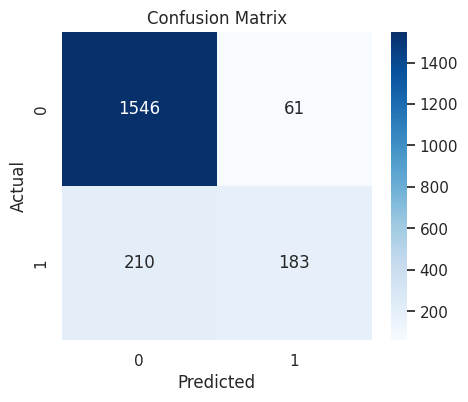

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



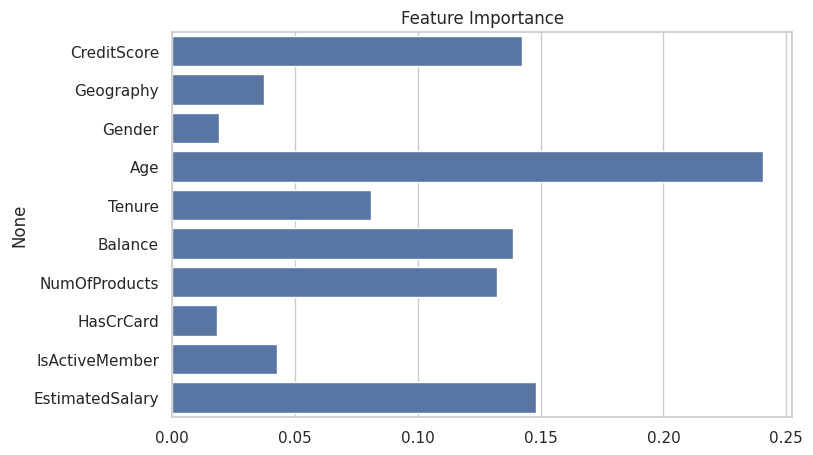


CONCLUSION:

A Random Forest model was used to predict customer churn.
Data was cleaned and categorical variables were encoded.

Feature importance shows which factors influence customer leaving behavior.
This helps banks improve customer retention strategies.



In [1]:
# =========================
# TASK 3: CUSTOMER CHURN PREDICTION
# =========================

#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

# =========================
# LOAD DATASET
# =========================
# Upload "Churn_Modelling.csv" in Colab

df = pd.read_csv("Churn_Modelling.csv")
print(df.head())

# =========================
# DATA EXPLORATION
# =========================
print(df.shape)
print(df.info())
print(df.isnull().sum())

# =========================
# DROP IRRELEVANT COLUMNS
# =========================
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# =========================
# ENCODE CATEGORICAL DATA
# =========================
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Geography"] = le.fit_transform(df["Geography"])

# =========================
# 📊 SPLIT DATA
# =========================
X = df.drop("Exited", axis=1)
y = df["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# MODEL TRAINING
# =========================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================
y_pred = model.predict(X_test)

# =========================
# EVALUATION
# =========================

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

# =========================
#  FEATURE IMPORTANCE
# =========================
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

# =========================
#  CONCLUSION
# =========================
print("""
CONCLUSION:

A Random Forest model was used to predict customer churn.
Data was cleaned and categorical variables were encoded.

Feature importance shows which factors influence customer leaving behavior.
This helps banks improve customer retention strategies.
""")